# Ensemble V30 詳細評価・分析

現在の結果を詳細に分析し、改善点を特定します。

In [1]:
import os
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict, List, Tuple, Any
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow import keras

# プロジェクトのルートディレクトリを追加
import sys
sys.path.append('..')

from src.utils.cmi_evaluation import calculate_cmi_score
from src.utils.pipeline import Preprocessor
from src.trainers.multimodal_trainer_v30 import MultimodalTrainerV30

# 日本語フォント設定
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

print("✅ ライブラリ読み込み完了")

2025-07-19 12:42:25.530889: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-19 12:42:25.573347: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752896545.586870 1209638 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752896545.590896 1209638 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752896545.603412 1209638 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

✅ ライブラリ読み込み完了


## データ読み込みと基本分析

In [2]:
# 設定
EXPERIMENT_NAME = "20250717_preproc_train_v30"
TRAINER_NAME = "20250717_preproc_train_v30"
N_FOLDS = 5
RANDOM_SEED = 42

# パス設定
BASE_DIR = Path("../output/experiments")
DATA_DIR = BASE_DIR / EXPERIMENT_NAME / "preprocessed"
MODEL_DIR = BASE_DIR / TRAINER_NAME / "models"
RESULT_DIR = BASE_DIR / TRAINER_NAME / "results"

print(f"実験名: {EXPERIMENT_NAME}")
print(f"データディレクトリ: {DATA_DIR}")
print(f"モデルディレクトリ: {MODEL_DIR}")
print(f"結果ディレクトリ: {RESULT_DIR}")

実験名: 20250717_preproc_train_v30
データディレクトリ: ../output/experiments/20250717_preproc_train_v30/preprocessed
モデルディレクトリ: ../output/experiments/20250717_preproc_train_v30/models
結果ディレクトリ: ../output/experiments/20250717_preproc_train_v30/results


In [3]:
# データ読み込み
def load_data() -> Dict[str, np.ndarray]:
    """前処理済みデータを読み込む"""
    print("📊 データ読み込み中...")
    
    def _load(name: str) -> np.ndarray:
        npy = DATA_DIR / f"{name}.npy"
        pkl = DATA_DIR / f"{name}.pkl"
        if npy.exists():
            return np.load(npy)
        if pkl.exists():
            with open(pkl, "rb") as f:
                return pickle.load(f)
        raise FileNotFoundError(f"{pkl} ファイルが見つかりません")
    
    X_sensor = _load("train_windows")
    X_demo = _load("train_demographics")
    X_tab = _load("train_tabular")
    X_tof = _load("train_tof_windows")
    y = _load("train_labels")
    info = _load("train_info")
    
    # グループ情報の抽出
    if isinstance(info, list) and len(info) > 0 and isinstance(info[0], dict):
        groups = np.array([
            d.get("subject") if d.get("subject") is not None else d.get("sequence_id")
            for d in info
        ])
    else:
        groups = np.asarray(info)
    
    return {
        "sensor": X_sensor,
        "demographics": X_demo,
        "tabular": X_tab,
        "tof": X_tof,
        "labels": y,
        "groups": groups,
    }

# データ読み込み
data = load_data()

# 基本統計
print("\n📈 データ基本統計:")
print(f"総サンプル数: {len(data['labels'])}")
print(f"クラス数: {len(np.unique(data['labels']))}")
print(f"ユニークグループ数: {len(np.unique(data['groups']))}")

# クラス分布
unique_labels, counts = np.unique(data['labels'], return_counts=True)
print(f"\nクラス分布:")
for label, count in zip(unique_labels, counts):
    print(f"  クラス {label}: {count}サンプル ({count/len(data['labels'])*100:.1f}%)")

# データ型と形状
print(f"\nデータ形状:")
print(f"  センサー: {data['sensor'].shape}, dtype: {data['sensor'].dtype}")
print(f"  人口統計: {data['demographics'].shape}, dtype: {data['demographics'].dtype}")
print(f"  表形式: {data['tabular'].shape}, dtype: {data['tabular'].dtype}")
print(f"  ToF: {data['tof'].shape}, dtype: {data['tof'].dtype}")

📊 データ読み込み中...

📈 データ基本統計:
総サンプル数: 8343
クラス数: 18
ユニークグループ数: 81

クラス分布:
  クラス 0: 638サンプル (7.6%)
  クラス 1: 642サンプル (7.7%)
  クラス 2: 161サンプル (1.9%)
  クラス 3: 657サンプル (7.9%)
  クラス 4: 641サンプル (7.7%)
  クラス 5: 179サンプル (2.1%)
  クラス 6: 640サンプル (7.7%)
  クラス 7: 643サンプル (7.7%)
  クラス 8: 166サンプル (2.0%)
  クラス 9: 642サンプル (7.7%)
  クラス 10: 735サンプル (8.8%)
  クラス 11: 161サンプル (1.9%)
  クラス 12: 477サンプル (5.7%)
  クラス 13: 165サンプル (2.0%)
  クラス 14: 672サンプル (8.1%)
  クラス 15: 481サンプル (5.8%)
  クラス 16: 482サンプル (5.8%)
  クラス 17: 161サンプル (1.9%)

データ形状:
  センサー: (8343, 128, 18), dtype: float32
  人口統計: (8343, 7), dtype: float32
  表形式: (8343, 389), dtype: float64
  ToF: (8343, 128, 5, 8, 8), dtype: float32


## クラス不均衡の分析

クラス不均衡比: 4.57
最大クラス: 735サンプル
最小クラス: 161サンプル


/tmp/ipykernel_1209638/101436714.py:49: UserWarning: Glyph 12463 (\N{KATAKANA LETTER KU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1209638/101436714.py:49: UserWarning: Glyph 12521 (\N{KATAKANA LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1209638/101436714.py:49: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1209638/101436714.py:49: UserWarning: Glyph 12469 (\N{KATAKANA LETTER SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1209638/101436714.py:49: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1209638/101436714.py:49: UserWarning: Glyph 12503 (\N{KATAKANA LETTER PU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1209638/101436714.py:49: UserWarning: Glyph 12523 (\N{KATAKANA LETTER RU}) missing from font(s) DejaVu Sans.
  plt.t

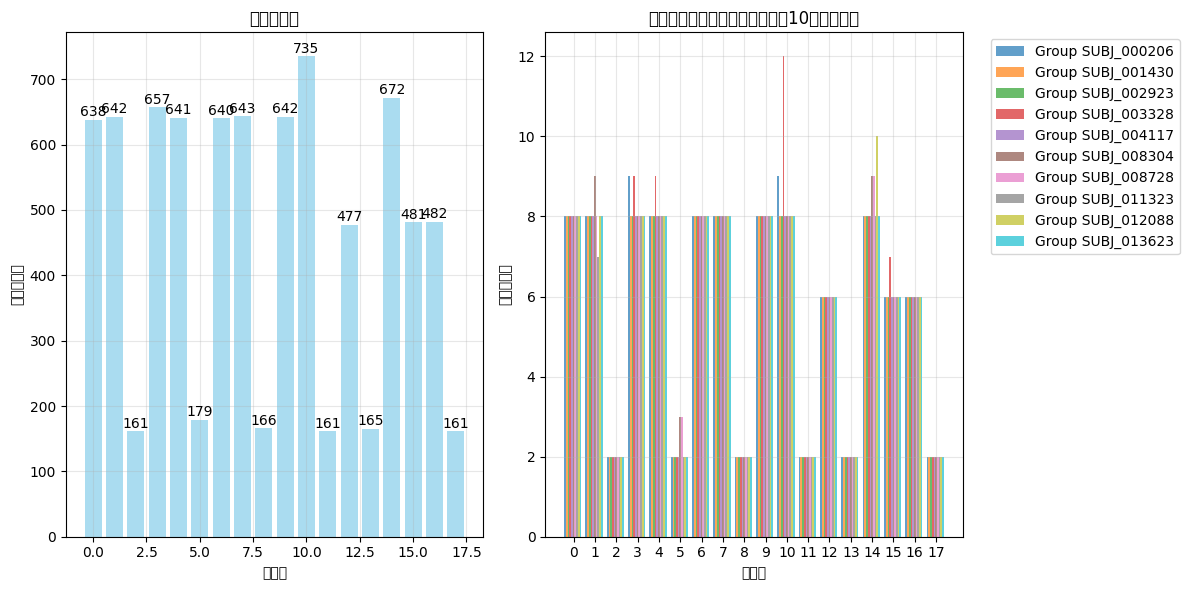

In [4]:
# クラス不均衡の可視化
plt.figure(figsize=(12, 6))

# クラス分布
plt.subplot(1, 2, 1)
unique_labels, counts = np.unique(data['labels'], return_counts=True)
bars = plt.bar(unique_labels, counts, alpha=0.7, color='skyblue')
plt.xlabel('クラス')
plt.ylabel('サンプル数')
plt.title('クラス分布')
plt.grid(True, alpha=0.3)

# バーに数値を表示
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             str(count), ha='center', va='bottom')

# 不均衡度の計算
imbalance_ratio = counts.max() / counts.min()
print(f"クラス不均衡比: {imbalance_ratio:.2f}")
print(f"最大クラス: {counts.max()}サンプル")
print(f"最小クラス: {counts.min()}サンプル")

# グループ別クラス分布
plt.subplot(1, 2, 2)
unique_groups = np.unique(data['groups'])
group_class_counts = {}

for group in unique_groups:
    group_mask = data['groups'] == group
    group_labels = data['labels'][group_mask]
    group_unique, group_counts = np.unique(group_labels, return_counts=True)
    group_class_counts[group] = dict(zip(group_unique, group_counts))

# グループ別のクラス分布を可視化（最初の10グループのみ）
sample_groups = list(unique_groups)[:10]
for i, group in enumerate(sample_groups):
    group_data = [group_class_counts[group].get(label, 0) for label in unique_labels]
    plt.bar(np.arange(len(unique_labels)) + i*0.08, group_data, 
            width=0.08, alpha=0.7, label=f'Group {group}')

plt.xlabel('クラス')
plt.ylabel('サンプル数')
plt.title('グループ別クラス分布（最初の10グループ）')
plt.xticks(np.arange(len(unique_labels)) + 0.4, unique_labels)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 各モダリティの特徴量分析

🔍 モダリティ特徴量分析


/tmp/ipykernel_1209638/2548057479.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/tmp/ipykernel_1209638/2548057479.py:52: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1209638/2548057479.py:52: UserWarning: Glyph 24500 (\N{CJK UNIFIED IDEOGRAPH-5FB4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1209638/2548057479.py:52: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1209638/2548057479.py:52: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1209638/2548057479.py:52: UserWarning: Glyph 20803 (\N{CJK UNIFIED IDEOGRAPH-5143}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/

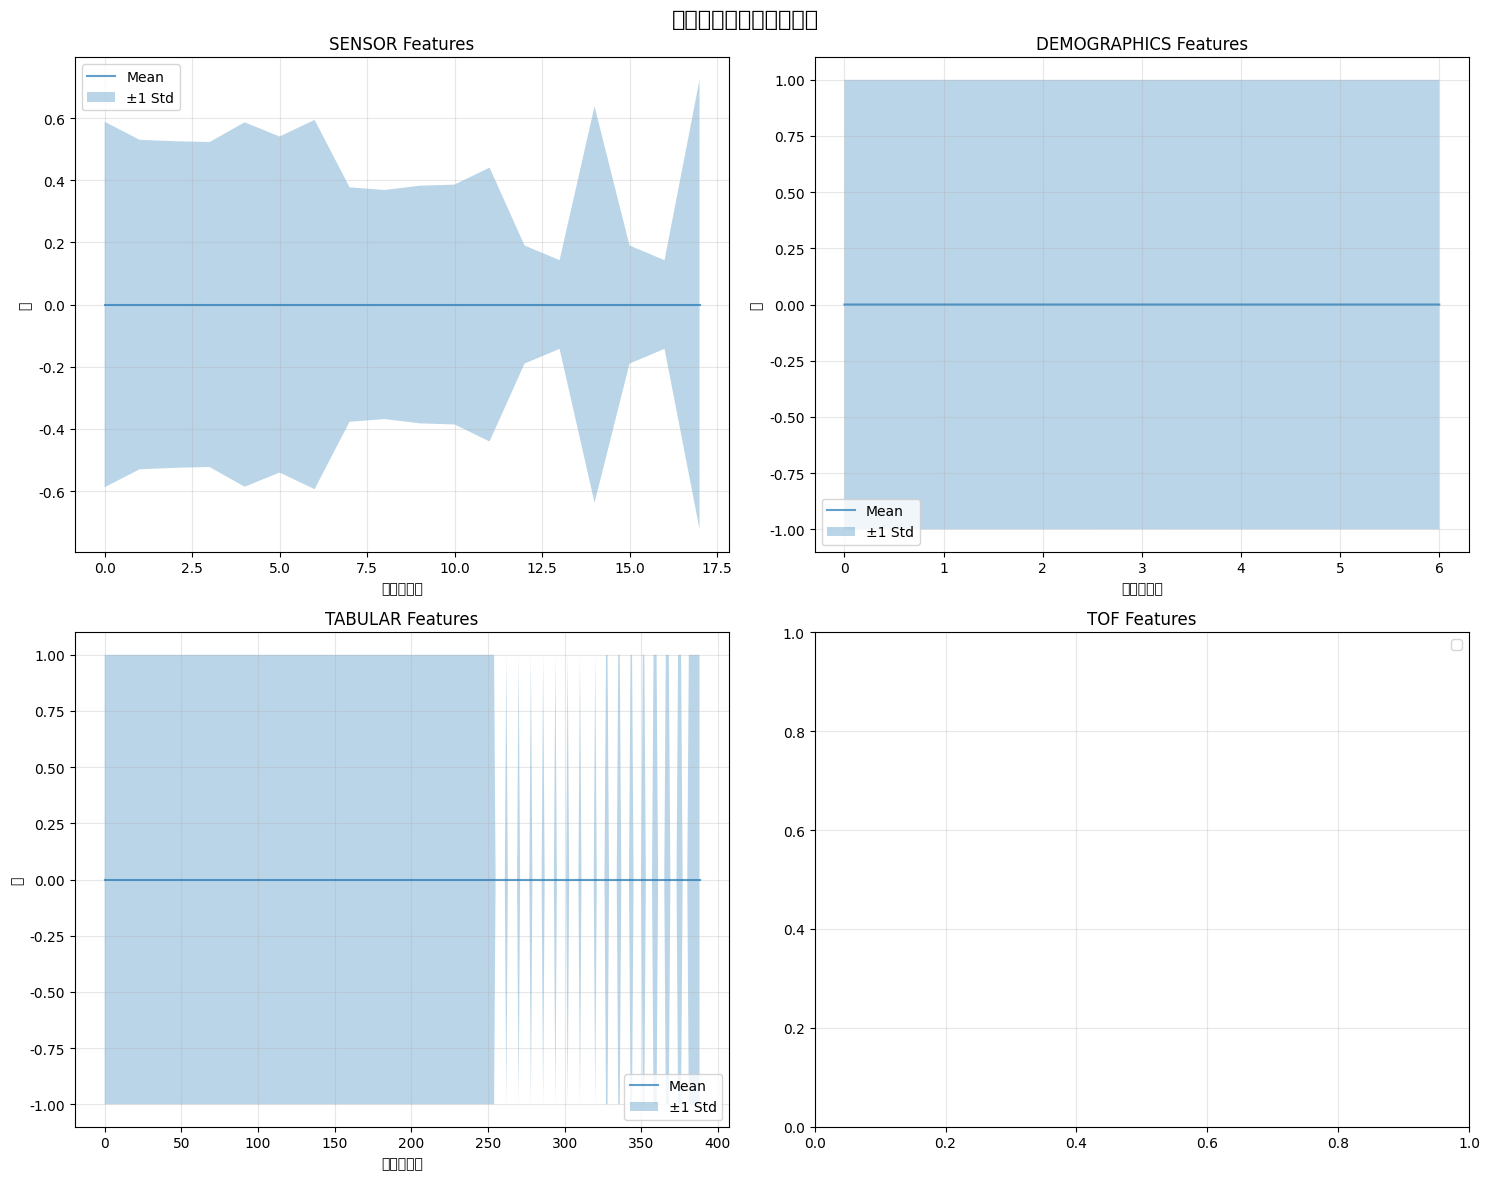


📊 モダリティ統計情報:

SENSOR:
  形状: (8343, 128, 18)
  平均: 0.0000
  標準偏差: 1.0000
  最小値: -22.7269
  最大値: 25.0743
  NaN: 0
  Inf: 0

DEMOGRAPHICS:
  形状: (8343, 7)
  平均: -0.0000
  標準偏差: 1.0000
  最小値: -3.0874
  最大値: 6.1873
  NaN: 0
  Inf: 0

TABULAR:
  形状: (8343, 389)
  平均: -0.0000
  標準偏差: 0.8604
  最小値: -20.0739
  最大値: 91.3345
  NaN: 0
  Inf: 0

TOF:
  形状: (8343, 128, 5, 8, 8)
  平均: -0.4010
  標準偏差: 0.8500
  最小値: -0.8638
  最大値: 2.3360
  NaN: 0
  Inf: 0


In [5]:
# 各モダリティの特徴量分析
def analyze_modality_features(data: Dict[str, np.ndarray]):
    """各モダリティの特徴量を分析"""
    print("🔍 モダリティ特徴量分析")
    
    modalities = {
        'sensor': data['sensor'],
        'demographics': data['demographics'],
        'tabular': data['tabular'],
        'tof': data['tof']
    }
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('モダリティ別特徴量分析', fontsize=16)
    
    for i, (name, features) in enumerate(modalities.items()):
        ax = axes[i//2, i%2]
        
        # 特徴量の統計
        if len(features.shape) == 2:
            # 2次元の場合
            mean_features = np.mean(features, axis=0)
            std_features = np.std(features, axis=0)
            
            ax.plot(mean_features, label='Mean', alpha=0.7)
            ax.fill_between(range(len(mean_features)), 
                           mean_features - std_features, 
                           mean_features + std_features, 
                           alpha=0.3, label='±1 Std')
            ax.set_xlabel('特徴量次元')
            ax.set_ylabel('値')
            
        elif len(features.shape) == 3:
            # 3次元の場合（センサー、ToF）
            # 時間軸で平均を取る
            mean_time = np.mean(features, axis=1)  # (samples, features)
            mean_features = np.mean(mean_time, axis=0)
            std_features = np.std(mean_time, axis=0)
            
            ax.plot(mean_features, label='Mean', alpha=0.7)
            ax.fill_between(range(len(mean_features)), 
                           mean_features - std_features, 
                           mean_features + std_features, 
                           alpha=0.3, label='±1 Std')
            ax.set_xlabel('特徴量次元')
            ax.set_ylabel('値')
        
        ax.set_title(f'{name.upper()} Features')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 統計情報を表示
    print("\n📊 モダリティ統計情報:")
    for name, features in modalities.items():
        print(f"\n{name.upper()}:")
        print(f"  形状: {features.shape}")
        print(f"  平均: {np.mean(features):.4f}")
        print(f"  標準偏差: {np.std(features):.4f}")
        print(f"  最小値: {np.min(features):.4f}")
        print(f"  最大値: {np.max(features):.4f}")
        print(f"  NaN: {np.isnan(features).sum()}")
        print(f"  Inf: {np.isinf(features).sum()}")

# 特徴量分析実行
analyze_modality_features(data)

## 詳細な評価結果の分析

In [6]:
# 保存された評価結果を読み込み
def load_evaluation_results():
    """保存された評価結果を読み込み"""
    eval_dir = Path("../output/experiments/eval_v30")
    
    if (eval_dir / "evaluation_results.json").exists():
        with open(eval_dir / "evaluation_results.json", "r", encoding="utf-8") as f:
            results = json.load(f)
        return results
    else:
        print("❌ 評価結果ファイルが見つかりません")
        return None

# 結果読み込み
eval_results = load_evaluation_results()

if eval_results:
    print("📊 評価結果分析:")
    
    # Fold別結果
    fold_results = eval_results['fold_results']
    
    print("\n各Foldの詳細結果:")
    for result in fold_results:
        print(f"Fold {result['fold']}:")
        print(f"  F1 Macro: {result['f1_macro']:.4f}")
        print(f"  CMI Score: {result['cmi_score']:.4f}")
        print(f"  Accuracy: {result['test_accuracy']:.4f}")
    
    # 統計情報
    f1_scores = [r['f1_macro'] for r in fold_results]
    cmi_scores = [r['cmi_score'] for r in fold_results]
    accuracies = [r['test_accuracy'] for r in fold_results]
    
    print(f"\n統計情報:")
    print(f"  F1 Macro - Mean: {np.mean(f1_scores):.4f}, Std: {np.std(f1_scores):.4f}")
    print(f"  CMI Score - Mean: {np.mean(cmi_scores):.4f}, Std: {np.std(cmi_scores):.4f}")
    print(f"  Accuracy - Mean: {np.mean(accuracies):.4f}, Std: {np.std(accuracies):.4f}")
    
    # アンサンブル結果
    ensemble_results = eval_results['ensemble_results']
    print(f"\nアンサンブル結果:")
    print(f"  F1 Macro: {ensemble_results['f1_macro']:.4f}")
    print(f"  CMI Score: {ensemble_results['cmi_score']:.4f}")
    print(f"  Accuracy: {ensemble_results['accuracy']:.4f}")

JSONDecodeError: Expecting value: line 9 column 22 (char 202)

## 改善提案

In [ ]:
# 改善提案の分析
def generate_improvement_suggestions(data: Dict[str, np.ndarray], eval_results: Dict = None):
    """改善提案を生成"""
    print("💡 改善提案")
    print("="*50)
    
    suggestions = []
    
    # 1. クラス不均衡の分析
    unique_labels, counts = np.unique(data['labels'], return_counts=True)
    imbalance_ratio = counts.max() / counts.min()
    
    if imbalance_ratio > 2.0:
        suggestions.append({
            'category': 'クラス不均衡',
            'issue': f'クラス不均衡比が{imbalance_ratio:.2f}と高い',
            'suggestions': [
                'クラス重みの調整',
                'SMOTE等のオーバーサンプリング',
                'アンダーサンプリング',
                'Focal Lossの使用'
            ]
        })
    
    # 2. データ品質の分析
    for name, features in [('sensor', data['sensor']), ('tof', data['tof'])]:
        if np.isnan(features).any() or np.isinf(features).any():
            suggestions.append({
                'category': 'データ品質',
                'issue': f'{name}データにNaN/Infが含まれている',
                'suggestions': [
                    '欠損値の適切な処理',
                    '異常値の除去',
                    'データクリーニングの強化'
                ]
            })
    
    # 3. モデルアーキテクチャの提案
    suggestions.append({
        'category': 'モデルアーキテクチャ',
        'issue': '現在のタワー型アーキテクチャの改善',
        'suggestions': [
            'Attention機構の導入',
            'Cross-modal fusionの改善',
            'Transformerベースのアーキテクチャ',
            'より深いネットワーク',
            'Residual connectionsの追加'
        ]
    })
    
    # 4. ハイパーパラメータの調整
    suggestions.append({
        'category': 'ハイパーパラメータ',
        'issue': '学習パラメータの最適化',
        'suggestions': [
            '学習率の調整',
            'バッチサイズの変更',
            'エポック数の増加',
            '正則化の強化',
            'Dropout率の調整'
        ]
    })
    
    # 5. 特徴量エンジニアリング
    suggestions.append({
        'category': '特徴量エンジニアリング',
        'issue': 'より効果的な特徴量の抽出',
        'suggestions': [
            '統計的特徴量の追加',
            'フーリエ変換による周波数特徴量',
            '時系列特徴量の抽出',
            '特徴量選択の実施',
            'PCAによる次元削減'
        ]
    })
    
    # 6. アンサンブル手法の改善
    if eval_results:
        f1_scores = [r['f1_macro'] for r in eval_results['fold_results']]
        if np.std(f1_scores) > 0.05:  # 分散が大きい場合
            suggestions.append({
                'category': 'アンサンブル手法',
                'issue': 'Fold間の分散が大きい',
                'suggestions': [
                    '異なるアーキテクチャの組み合わせ',
                    '重み付きアンサンブル',
                    'Stacking手法の導入',
                    'より多くのfoldでの評価'
                ]
            })
    
    # 提案を表示
    for i, suggestion in enumerate(suggestions, 1):
        print(f"\n{i}. {suggestion['category']}: {suggestion['issue']}")
        print("   改善案:")
        for j, improvement in enumerate(suggestion['suggestions'], 1):
            print(f"     {j}. {improvement}")
    
    return suggestions

# 改善提案生成
improvement_suggestions = generate_improvement_suggestions(data, eval_results)

## 優先度付き改善計画

In [ ]:
# 優先度付き改善計画
def create_improvement_plan(suggestions: List[Dict]):
    """優先度付き改善計画を作成"""
    print("\n📋 優先度付き改善計画")
    print("="*50)
    
    # 優先度の定義
    priority_order = [
        'データ品質',
        'クラス不均衡',
        'ハイパーパラメータ',
        '特徴量エンジニアリング',
        'モデルアーキテクチャ',
        'アンサンブル手法'
    ]
    
    # 優先度順にソート
    sorted_suggestions = sorted(suggestions, 
                               key=lambda x: priority_order.index(x['category']) 
                               if x['category'] in priority_order else len(priority_order))
    
    print("\n🎯 即座に実施すべき項目（高優先度）:")
    high_priority = [s for s in sorted_suggestions if s['category'] in ['データ品質', 'クラス不均衡']]
    for i, suggestion in enumerate(high_priority, 1):
        print(f"  {i}. {suggestion['category']}: {suggestion['issue']}")
        print(f"     最初の改善案: {suggestion['suggestions'][0]}")
    
    print("\n🔧 短期改善項目（中優先度）:")
    medium_priority = [s for s in sorted_suggestions if s['category'] in ['ハイパーパラメータ', '特徴量エンジニアリング']]
    for i, suggestion in enumerate(medium_priority, 1):
        print(f"  {i}. {suggestion['category']}: {suggestion['issue']}")
        print(f"     推奨改善案: {suggestion['suggestions'][0]}")
    
    print("\n🚀 長期改善項目（低優先度）:")
    low_priority = [s for s in sorted_suggestions if s['category'] in ['モデルアーキテクチャ', 'アンサンブル手法']]
    for i, suggestion in enumerate(low_priority, 1):
        print(f"  {i}. {suggestion['category']}: {suggestion['issue']}")
        print(f"     検討改善案: {suggestion['suggestions'][0]}")
    
    # 具体的なアクションプラン
    print("\n📝 具体的なアクションプラン:")
    print("1. データ品質チェックとクリーニング")
    print("2. クラス重みの調整とFocal Lossの実装")
    print("3. ハイパーパラメータのグリッドサーチ")
    print("4. 追加特徴量の抽出と選択")
    print("5. アーキテクチャの改良とテスト")
    print("6. アンサンブル手法の最適化")

# 改善計画作成
create_improvement_plan(improvement_suggestions)